In [37]:
# # Inference notebook for trained LC2Img model

# import torch
# import matplotlib.pyplot as plt
# from data.dataset import StarryNPZDataset
# from trainers.lc2img_module import LC2ImgModule
# from torch.utils.data import DataLoader
# import numpy as np
# import os

# # Paths and parameters (modify accordingly)
# MODEL_PATH = './output/final_model.pt'
# DATA_PATH = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/starmap/starmap4astron/synthetic_data_output/dataset2/synthetic_starry_data_part_0.npz'
# IMG_SIZE = 64
# LATENT_CHANNELS = 256
# GRID_SIZE = (8, 8)
# BASE_CHANNELS = 64

# # Load the trained model
# model = LC2ImgModule(
#     latent_channels=LATENT_CHANNELS,
#     grid_size=GRID_SIZE,
#     img_size=IMG_SIZE,
#     base_channels=BASE_CHANNELS,
#     mask_corners=False     # ← register circle_mask buffer
# )

# model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
# model.eval()

# # Load the dataset
# dataset = StarryNPZDataset(
#     path=DATA_PATH,
#     lc_key='flux',
#     img_key='image',
#     img_size=IMG_SIZE
# )

# # Select 4 random examples
# indices = np.random.choice(len(dataset), size=4, replace=False)

# fig, axes = plt.subplots(4, 2, figsize=(8, 16))

# with torch.no_grad():
#     for idx, data_idx in enumerate(indices):
#         lc, true_img = dataset[data_idx]

#         # Run inference
#         pred_img = model(lc.unsqueeze(0)).squeeze().cpu().numpy()

#         # Plot true image
#         axes[idx, 0].imshow(true_img.squeeze(), cmap='plasma')
#         axes[idx, 0].set_title(f"True Image {data_idx}")
#         axes[idx, 0].axis('off')

#         # Plot predicted image
#         axes[idx, 1].imshow(pred_img.squeeze(), cmap='plasma')
#         axes[idx, 1].set_title(f"Predicted Image {data_idx}")
#         axes[idx, 1].axis('off')

# plt.tight_layout()
# plt.show()


In [38]:
# import json
# import os
# import matplotlib.pyplot as plt

# LOSS_JSON_PATH = './output/loss_data.json'

# # Load loss data from JSON file
# if os.path.exists(LOSS_JSON_PATH):
#     with open(LOSS_JSON_PATH, 'r') as f:
#         loss_data = json.load(f)

#     train_losses = loss_data["train_losses"]
#     val_losses = loss_data["val_losses"]
#     epochs = range(1, len(train_losses) + 1)

#     plt.figure(figsize=(10, 6))
#     plt.plot(epochs, np.log(train_losses), label='Train Loss')
#     plt.plot(epochs, np.log(val_losses[1:]), label='Validation Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('log(Loss)')
#     plt.title('Training and Validation Loss Curves')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()


#     # plt.ylim(0.006, 2)

#     plt.show()

# else:
#     print(f"Loss JSON file not found at {LOSS_JSON_PATH}")


In [39]:
# import torch
# import matplotlib.pyplot as plt
# from data.dataset import StarryNPZDataset
# from torch.utils.data import DataLoader
# import numpy as np
# import os

# # ─────────────────────────────────────────────────────────────────────────────
# # Toggle this flag:
# v2 = True  # ← set True to use the new LC2ImgModuleV2 architecture
# # ─────────────────────────────────────────────────────────────────────────────

# # Paths and parameters (modify accordingly)
# MODEL_PATH    = './output/final_model.pt'
# DATA_PATH     = '/path/to/synthetic_starry_data_part_0.npz'
# IMG_SIZE      = 64
# LATENT_CHANS  = 256
# GRID_SIZE     = (8, 8)
# BASE_CHS      = 64

# # Conditional import / instantiation
# if not v2:
#     from trainers.lc2img_module import LC2ImgModule
#     model = LC2ImgModule(
#         latent_channels=LATENT_CHANS,
#         grid_size=GRID_SIZE,
#         img_size=IMG_SIZE,
#         base_channels=BASE_CHS,
#         mask_corners=False
#     )
# else:
#     # assumes you’ve implemented your new version under this name & path:
#     from trainers.lc2img_module import LC2ImgModule
#     model = LC2ImgModule(
#         latent_channels=LATENT_CHANS,
#         grid_size=GRID_SIZE,
#         img_size=IMG_SIZE,
#         base_channels=BASE_CHS,
#         mask_corners=False,
#         # you can pass any extra v2-specific args here
#     )

# # Load weights
# state = torch.load(MODEL_PATH, map_location='cpu')
# model.load_state_dict(state)
# model.eval()

# # Prepare dataset + sampler
# dataset = StarryNPZDataset(
#     path=DATA_PATH,
#     lc_key='flux',
#     img_key='image',
#     img_size=IMG_SIZE
# )

# # Sample 4 random examples
# indices = np.random.choice(len(dataset), size=4, replace=False)

# # Plotting
# fig, axes = plt.subplots(4, 2, figsize=(8, 16))
# with torch.no_grad():
#     for row, idx in enumerate(indices):
#         lc, true_img = dataset[idx]
#         pred = model(lc.unsqueeze(0))     # (1,1,H,W)
#         pred = pred.squeeze().cpu().numpy()

#         # True
#         axes[row, 0].imshow(true_img.squeeze(), cmap='plasma')
#         axes[row, 0].set_title(f"True #{idx}")
#         axes[row, 0].axis('off')

#         # Predicted
#         axes[row, 1].imshow(pred.squeeze(), cmap='plasma')
#         axes[row, 1].set_title(f"Pred #{idx}")
#         axes[row, 1].axis('off')

# plt.tight_layout()
# plt.show()


In [3]:
#check the current working directory
import os
print(os.getcwd())
#change to ./starmap4astron
os.chdir('./starmap/starmap4astron')
print(os.getcwd())

/pdo/users/pablomer
/pdo/users/pablomer/starmap/starmap4astron


Loaded config: {'data_dir': '/pdo/users/pablomer/starmap/starmap4astron/synthetic_data_output/dataset_combined/synthetic_starry_data_combined.npz', 'val_data_dir': None, 'val_split': 0.1, 'batch_size': 32, 'img_size': 256, 'latent_channels': 128, 'grid_h': 16, 'grid_w': 16, 'base_channels': 64, 'num_pyramid': 3, 'use_residuals': True, 'res_dilations': [1, 2, 4, 8], 'mask_corners': True, 'lr': 0.0005, 'max_epochs': 50, 'gpus': 1, 'output_dir': './output_Apr28', 'use_perceptual_loss': False, 'use_ssim_loss': True, 'lambda_perc': 0.1, 'lambda_ssim': 0.1}
Model path: ./output_Apr28/final_model.pt
Data path: /pdo/users/pablomer/starmap/starmap4astron/synthetic_data_output/dataset_combined/synthetic_starry_data_combined.npz
Image size: 256
Grid size: (16, 16)
Latent channels: 128
Base channels: 64
Num pyramid: 3
Use residuals: True
Residual dilations: [1, 2, 4, 8]
Mask corners: True
Use perceptual loss: False
Use SSIM loss: True
Lambda perceptual: 0.1
Lambda SSIM: 0.1
Using SSIM loss


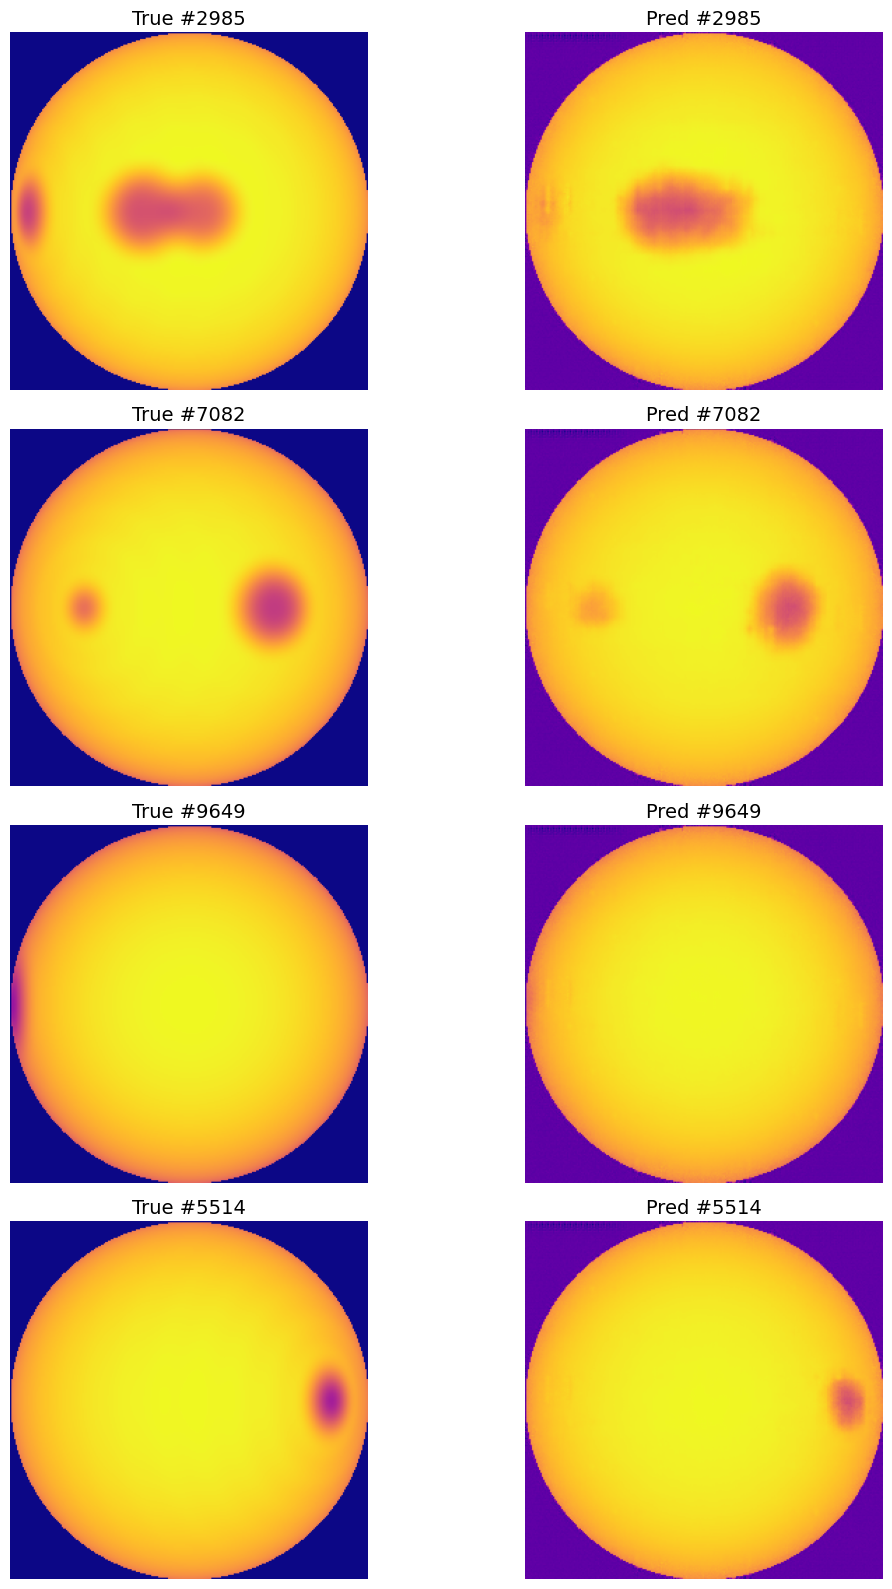

In [36]:
import json
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from data.dataset import StarryNPZDataset
from trainers.lc2img_module import LC2ImgModule

# ────────────────────────────────────────────────────────────────────────────
# 1) Load config.json from your run
# ────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "./output_Apr28"  # or wherever you trained
with open(os.path.join(OUTPUT_DIR, "config.json"), "r") as f:
    cfg = json.load(f)

MODEL_PATH     = os.path.join(OUTPUT_DIR, "final_model.pt")
DATA_PATH      = cfg["data_dir"]
IMG_SIZE       = cfg["img_size"]
LATENT_CHANS   = cfg["latent_channels"]
GRID_SIZE      = (cfg["grid_h"], cfg["grid_w"])
BASE_CHANNELS  = cfg["base_channels"]
NUM_PYRAMID    = cfg.get("num_pyramid", 3)
USE_RESIDUALS  = cfg.get("use_residuals", False)
RES_DILATIONS  = cfg.get("res_dilations", [1,2,4,8])
MASK_CORNERS   = cfg.get("mask_corners", False)
PERCEPTUAL_LOSS = cfg.get("use_perceptual_loss", True)
USE_SSIM        = cfg.get("use_ssim_loss", True)
LAMBDA_PERC     = cfg.get("lambda_perc", 0)
LAMBDA_SSIM     = cfg.get("lambda_ssim", 0)

print("Loaded config:", cfg)
print("Model path:", MODEL_PATH)
print("Data path:", DATA_PATH)
print("Image size:", IMG_SIZE)
print("Grid size:", GRID_SIZE)
print("Latent channels:", LATENT_CHANS)
print("Base channels:", BASE_CHANNELS)
print("Num pyramid:", NUM_PYRAMID)
print("Use residuals:", USE_RESIDUALS)
print("Residual dilations:", RES_DILATIONS)
print("Mask corners:", MASK_CORNERS)
print("Use perceptual loss:", PERCEPTUAL_LOSS)
print("Use SSIM loss:", USE_SSIM)
print("Lambda perceptual:", LAMBDA_PERC)
print("Lambda SSIM:", LAMBDA_SSIM)

# ────────────────────────────────────────────────────────────────────────────
# 2) Instantiate & load the model using the same args
# ────────────────────────────────────────────────────────────────────────────
# model = LC2ImgModule(
#     lr               = cfg["lr"],
#     latent_channels  = LATENT_CHANS,
#     grid_size        = GRID_SIZE,
#     img_size         = IMG_SIZE,
#     base_channels    = BASE_CHANNELS,
#     num_pyramid      = NUM_PYRAMID,
#     use_residuals    = USE_RESIDUALS,
#     res_dilations    = RES_DILATIONS,
#     mask_corners     = MASK_CORNERS,
# )


model = LC2ImgModule(
    lr               = cfg["lr"],
    latent_channels  = LATENT_CHANS,
    grid_size        = GRID_SIZE,
    img_size         = IMG_SIZE,
    base_channels    = BASE_CHANNELS,
    num_pyramid      = NUM_PYRAMID,
    use_residuals    = USE_RESIDUALS,
    res_dilations    = RES_DILATIONS,
    mask_corners     = MASK_CORNERS,

    # ← these two must match your training run
    use_perceptual_loss = PERCEPTUAL_LOSS,
    use_ssim_loss       = USE_SSIM,
    lambda_perc         = LAMBDA_PERC,
    lambda_ssim         = LAMBDA_SSIM,
)


model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()

# ────────────────────────────────────────────────────────────────────────────
# 3) Load dataset & run inference just like before
# ────────────────────────────────────────────────────────────────────────────
dataset = StarryNPZDataset(
    path     = DATA_PATH,
    lc_key   = 'flux',
    img_key  = 'image',
    img_size = IMG_SIZE
)

n=4
# np.random.seed(46)
np.random.seed(54)
#62


indices = np.random.choice(len(dataset), size=n, replace=False)
fig, axes = plt.subplots(n, 2, figsize=(12, 16))

with torch.no_grad():
    for row, idx in enumerate(indices):
        lc, true_img = dataset[idx]
        pred_img = model(lc.unsqueeze(0)).squeeze().cpu().numpy()
        flux = lc.squeeze().cpu().numpy()
        axes[row, 0].imshow(true_img.squeeze(), cmap='plasma')
        axes[row, 0].set_title(f"True #{idx}",fontsize=14)
        # axes[row, 0].set_title(f"True Image",fontsize=22)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(pred_img.squeeze(), cmap='plasma')
        axes[row, 1].set_title(f"Pred #{idx}", fontsize=14)
        # axes[row, 1].set_title(f"Pred Img", fontsize=22)
        axes[row, 1].axis('off')

        # # Column 2: light-curve
        # ax_lc = axes[row, 2]
        # ax_lc.plot(flux)
        # ax_lc.set_title("Input light-curve", fontsize=22)
        # # Remove y ticks
        # ax_lc.set_xticks([])
        # ax_lc.set_yticks([])
        # ax_lc.set_xlabel("Time", fontsize=22)
        # ax_lc.set_ylabel("Flux", fontsize=22)
        # ax_lc.grid(True)

plt.tight_layout()
plt.show()


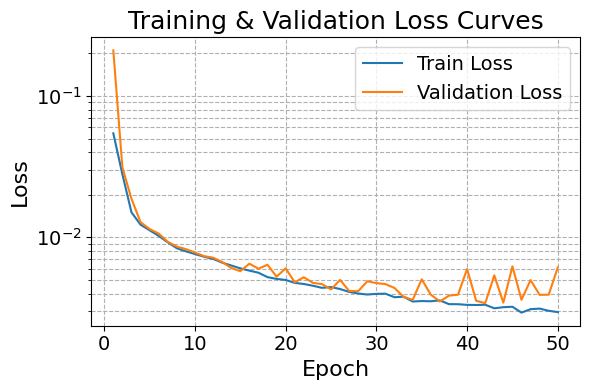

In [47]:
# ────────────────────────────────────────────────────────────────────────────
# Cell 2: Plot training & validation loss curves (log scale)
# ────────────────────────────────────────────────────────────────────────────
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# Path to your loss data JSON
LOSS_JSON_PATH = os.path.join(OUTPUT_DIR, "loss_data.json")

if os.path.exists(LOSS_JSON_PATH):
    with open(LOSS_JSON_PATH, 'r') as f:
        loss_data = json.load(f)

    train_losses = loss_data["train_losses"]
    val_losses   = loss_data["val_losses"]
    epochs       = np.arange(1, len(train_losses) + 1)
    n= len(epochs)

    plt.figure(figsize=(6, 4))
    plt.semilogy(epochs, train_losses, label='Train Loss')
    plt.semilogy(epochs, val_losses[:n],   label='Validation Loss')

    # axis labels
    plt.xlabel('Epoch',   fontsize=16)
    plt.ylabel('Loss',    fontsize=16)
    # title
    plt.title('Training & Validation Loss Curves', fontsize=18)

    # tick labels
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=14)
    plt.grid(True, which='both', ls='--')
    plt.tight_layout()
    plt.show()

else:
    print(f"❌ Loss JSON file not found at {LOSS_JSON_PATH}")
